# 🧩Data Wrangling

## import csv_file & Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("online_course_engagement_data.csv")

## Exploratory  Data

In [2]:
df.head(10)

,UserID,CourseCategory,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
0,5618,Health,29.979719,17,3,50.365656,20.860773,1,0
1,4326,Arts,27.802640,1,5,62.615970,65.632415,1,0
2,5849,Arts,86.820485,14,2,78.458962,63.812007,1,1
3,4992,Science,35.038427,17,10,59.198853,95.433162,0,1
4,3866,Programming,92.490647,16,0,98.428285,18.102478,0,0
5,8650,Health,79.466129,12,7,70.233329,76.484023,0,1
6,4321,Health,78.908724,10,2,86.836533,22.588896,1,0
7,4589,Business,12.068237,16,3,61.553646,27.410991,1,0
8,4215,Business,81.935709,8,4,90.264564,33.308437,0,1
9,8089,Programming,83.394026,15,10,63.956353,33.261300,1,0


In [3]:
df.describe()

,UserID,TimeSpentOnCourse,NumberOfVideosWatched,NumberOfQuizzesTaken,QuizScores,CompletionRate,DeviceType,CourseCompletion
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4498.894556,50.163822,10.024667,5.090556,74.706028,50.340146,0.500667,0.396444
std,2596.849433,28.491750,6.029878,3.157762,14.378383,28.950977,0.500027,0.489186
min,1.000000,1.005230,0.000000,0.000000,50.005119,0.009327,0.000000,0.000000
25%,2251.750000,25.440548,5.000000,2.000000,62.283451,25.653614,0.000000,0.000000
50%,4483.500000,49.818417,10.000000,5.000000,74.743294,50.264124,1.000000,0.000000
75%,6751.250000,75.069924,15.000000,8.000000,87.022663,75.572493,1.000000,1.000000
max,9000.000000,99.992558,20.000000,10.000000,99.994984,99.979711,1.000000,1.000000


In [4]:
df.columns

Index(['UserID', 'CourseCategory', 'TimeSpentOnCourse',
       'NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'CompletionRate', 'DeviceType', 'CourseCompletion'],
      dtype='object')

In [5]:
df.shape

(9000, 9)

In [6]:
df.dtypes


UserID                     int64
CourseCategory            object
TimeSpentOnCourse        float64
NumberOfVideosWatched      int64
NumberOfQuizzesTaken       int64
QuizScores               float64
CompletionRate           float64
DeviceType                 int64
CourseCompletion           int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UserID                 9000 non-null   int64  
 1   CourseCategory         9000 non-null   object 
 2   TimeSpentOnCourse      9000 non-null   float64
 3   NumberOfVideosWatched  9000 non-null   int64  
 4   NumberOfQuizzesTaken   9000 non-null   int64  
 5   QuizScores             9000 non-null   float64
 6   CompletionRate         9000 non-null   float64
 7   DeviceType             9000 non-null   int64  
 8   CourseCompletion       9000 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 632.9+ KB


In [8]:
df.isnull().sum()

UserID                   0
CourseCategory           0
TimeSpentOnCourse        0
NumberOfVideosWatched    0
NumberOfQuizzesTaken     0
QuizScores               0
CompletionRate           0
DeviceType               0
CourseCompletion         0
dtype: int64

## Handling dublicate_values

In [9]:
print(f"num of duplicate value before handle : {df.duplicated().sum()}")

num of duplicate value before handle : 877


In [10]:
df.drop_duplicates(inplace=True)
print(f"num of duplicate value after handled : {df.duplicated().sum()}")

num of duplicate value after handled : 0


In [11]:
df["CourseCategory"]=df["CourseCategory"].str.upper()

df["CourseCategory"]=df["CourseCategory"].str.replace(r'[^0-9A-z\s]','',regex=True)

## Handling Outliers

In [12]:
Outlier=["TimeSpentOnCourse","NumberOfVideosWatched","NumberOfQuizzesTaken","QuizScores","QuizScores"]
for i in Outlier:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    Lower_bound=Q1-IQR*1.5
    Upper_bound=Q3+IQR*1.5

    df=df[(df[i]>=Lower_bound) & (df[i]<=Upper_bound)]

#  🧩Exploratory Data Analysis (EDA) 

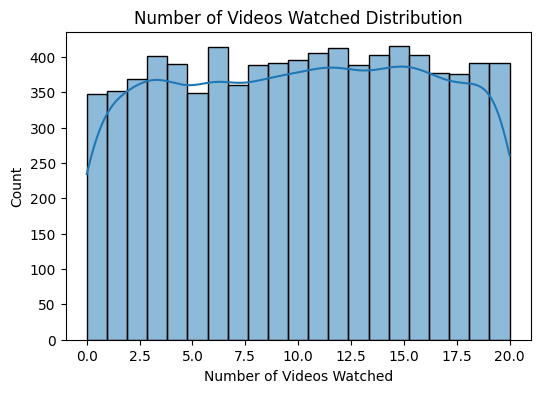

In [13]:

plt.figure(figsize=(6,4))
sns.histplot(df['NumberOfVideosWatched'], kde=True)
plt.title("Number of Videos Watched Distribution")
plt.xlabel("Number of Videos Watched")
plt.ylabel("Count")
plt.show()

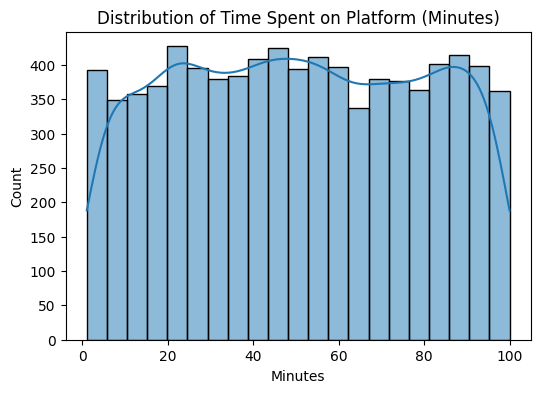

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['TimeSpentOnCourse'], kde=True)
plt.title("Distribution of Time Spent on Platform (Minutes)")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

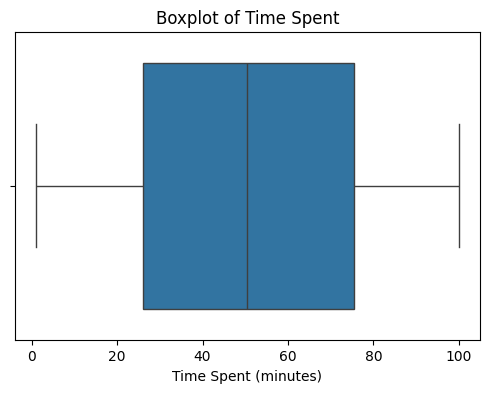

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TimeSpentOnCourse'])
plt.title("Boxplot of Time Spent")
plt.xlabel("Time Spent (minutes)")
plt.show()

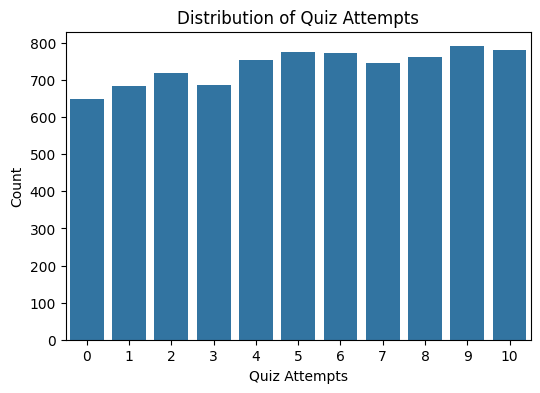

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='NumberOfQuizzesTaken', data=df)
plt.title("Distribution of Quiz Attempts")
plt.xlabel("Quiz Attempts")
plt.ylabel("Count")
plt.show()

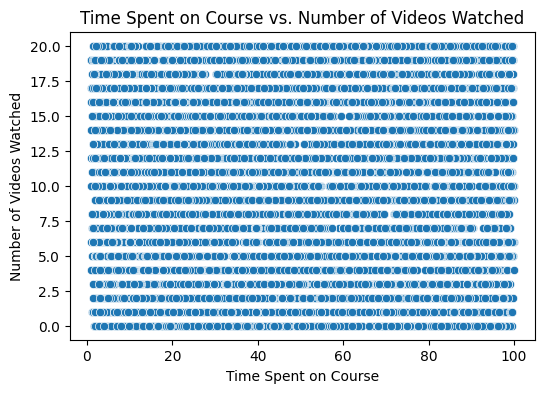

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TimeSpentOnCourse', y='NumberOfVideosWatched', data=df)
plt.title("Time Spent on Course vs. Number of Videos Watched")
plt.xlabel("Time Spent on Course")
plt.ylabel("Number of Videos Watched")
plt.show()

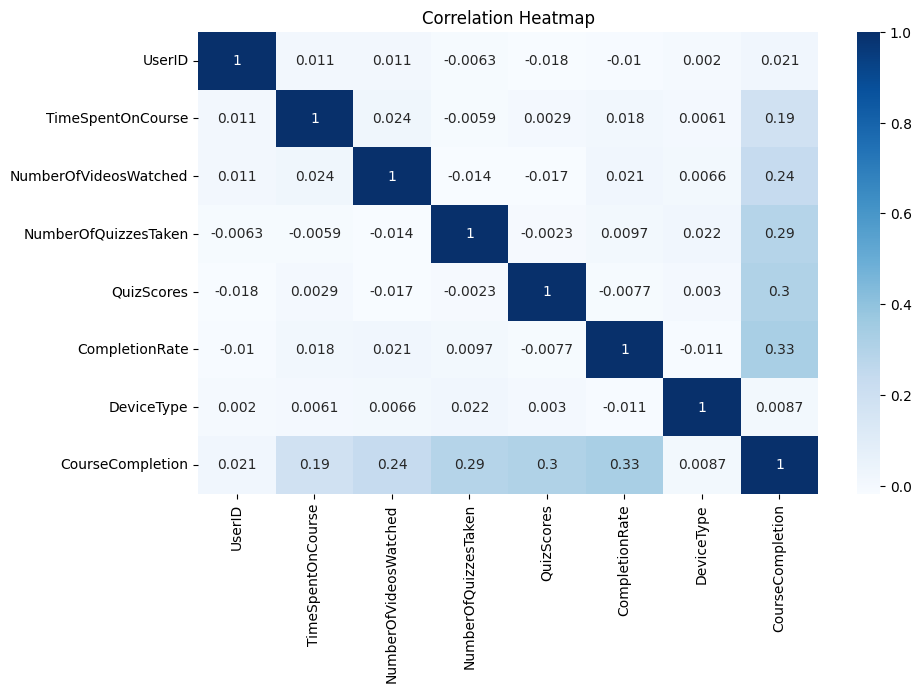

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

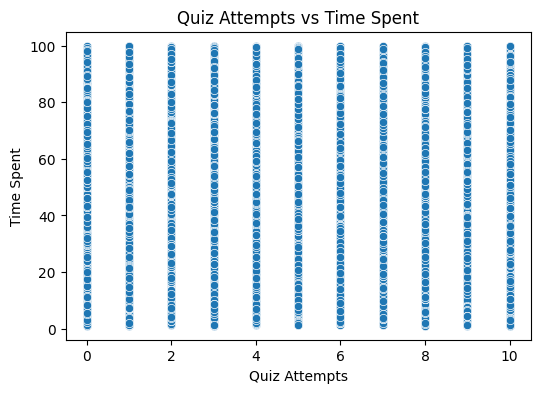

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='NumberOfQuizzesTaken', y='TimeSpentOnCourse', data=df) # Corrected column names
plt.title("Quiz Attempts vs Time Spent")
plt.xlabel("Quiz Attempts")
plt.ylabel("Time Spent")
plt.show()

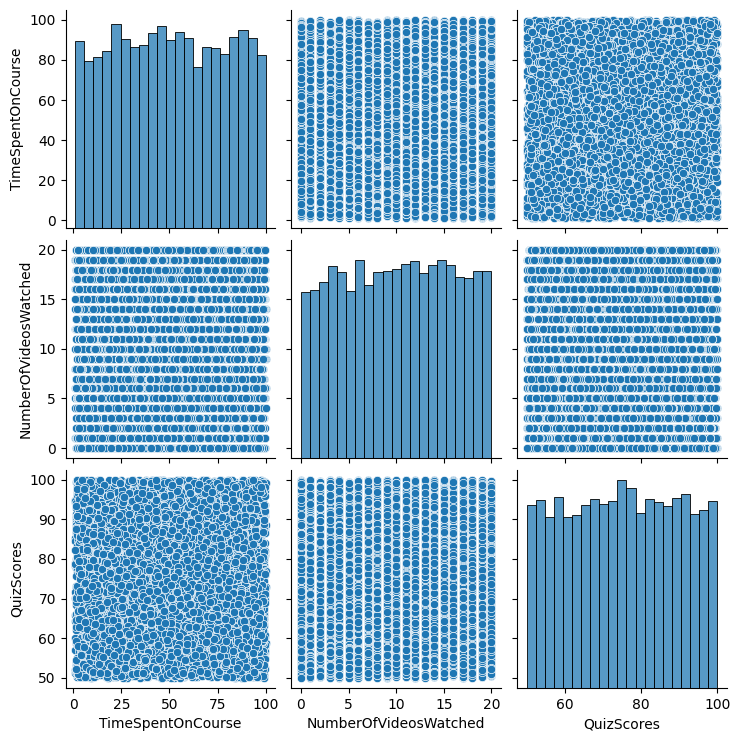

In [20]:
sns.pairplot(df[['TimeSpentOnCourse', 'NumberOfVideosWatched', 'QuizScores']])
plt.show()

# 🧩Feature Engineering & Selection


In [21]:
df["activity_score"] = (df["NumberOfVideosWatched"] * 0.3 +df["TimeSpentOnCourse"] * 0.5 +df["NumberOfQuizzesTaken"] * 0.2)

In [22]:
df["engagement_level"] = pd.cut(
    df["activity_score"],
    bins=[0, 20, 50, 100, 200],
    labels=["Low", "Medium", "High", "Very High"]
)

In [23]:
df["time_spent_norm"] = (
    df["TimeSpentOnCourse"] - df["TimeSpentOnCourse"].min()
) / (
    df["TimeSpentOnCourse"].max() - df["TimeSpentOnCourse"].min()
)

In [24]:
le = LabelEncoder()
df["passed_encoded"] = le.fit_transform(df["CourseCompletion"])

df = pd.get_dummies(df, columns=["engagement_level"], drop_first=True)

In [25]:
correlation = df.corr(numeric_only=True)["passed_encoded"].sort_values(ascending=False)
correlation


CourseCompletion              1.000000
passed_encoded                1.000000
CompletionRate                0.328800
QuizScores                    0.304706
NumberOfQuizzesTaken          0.291650
NumberOfVideosWatched         0.239476
activity_score                0.226970
TimeSpentOnCourse             0.186399
time_spent_norm               0.186399
engagement_level_Medium       0.160040
engagement_level_High         0.093293
UserID                        0.021000
DeviceType                    0.008663
engagement_level_Very High         NaN
Name: passed_encoded, dtype: float64

In [26]:
X = df.drop(["CourseCompletion", "passed_encoded"], axis=1)
X = X.select_dtypes(include="number")

y = df["passed_encoded"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y)

lasso_importance = pd.Series(lasso.coef_, index=X.columns)
lasso_importance.sort_values(ascending=False)

CompletionRate           0.149304
QuizScores               0.144311
NumberOfQuizzesTaken     0.132119
NumberOfVideosWatched    0.097995
activity_score           0.080098
UserID                   0.003313
TimeSpentOnCourse        0.000000
DeviceType               0.000000
time_spent_norm          0.000000
dtype: float64

In [27]:
model = LogisticRegression(max_iter=200)
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X,y)

X.columns[rfe.support_]

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Index(['NumberOfVideosWatched', 'NumberOfQuizzesTaken', 'QuizScores',
       'activity_score', 'time_spent_norm'],
      dtype='object')

# 🧩 Probability & Hypothesis Testing

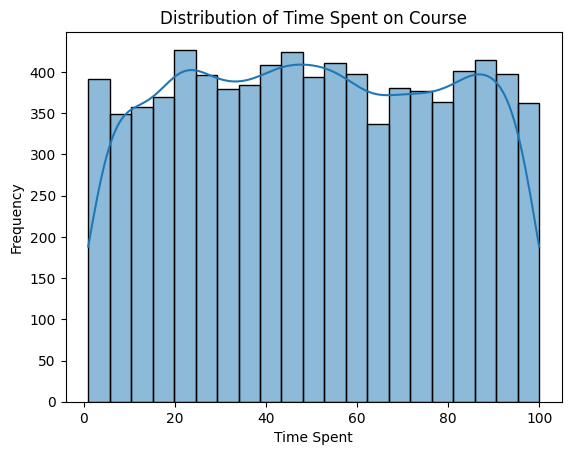

In [28]:
sns.histplot(df['TimeSpentOnCourse'], kde=True)
plt.title("Distribution of Time Spent on Course")
plt.xlabel("Time Spent")
plt.ylabel("Frequency")
plt.show()




In [29]:
stat, p_value = stats.normaltest(df['TimeSpentOnCourse'])
p_value

np.float64(0.0)

In [30]:
mu = df['TimeSpentOnCourse'].mean()
sigma = df['TimeSpentOnCourse'].std()

probability = 1 - stats.norm.cdf(60, mu, sigma)
probability
completed = df[df['CourseCompletion'] == 1]['TimeSpentOnCourse']
not_completed = df[df['CourseCompletion'] == 0]['TimeSpentOnCourse']



In [31]:
stat, p_value = stats.ttest_ind(
    completed,
    not_completed,
    equal_var=False
)
p_value

np.float64(1.3262476318084054e-66)

# 🧩 Dimensionality Reduction (PCA)

##  1️⃣ Data Standardization

In [32]:
# Select engagement-related numerical features
features = [
"TimeSpentOnCourse",
"NumberOfVideosWatched",
"NumberOfQuizzesTaken",
"QuizScores",
"CompletionRate"
]

X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2️⃣ Applying PCA

### We applied PCA to reduce the dataset to two principal components, which allows effective visualization while retaining a high proportion of the original variance.

In [33]:


# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])


# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Total Variance Explained:", explained_variance.sum())

Explained Variance Ratio: [0.20933716 0.20194549]
Total Variance Explained: 0.4112826491646862


## 3️⃣ PCA Visualization

###  To visually inspect engagement patterns and potential clusters among students, we plotted the first two principal components.

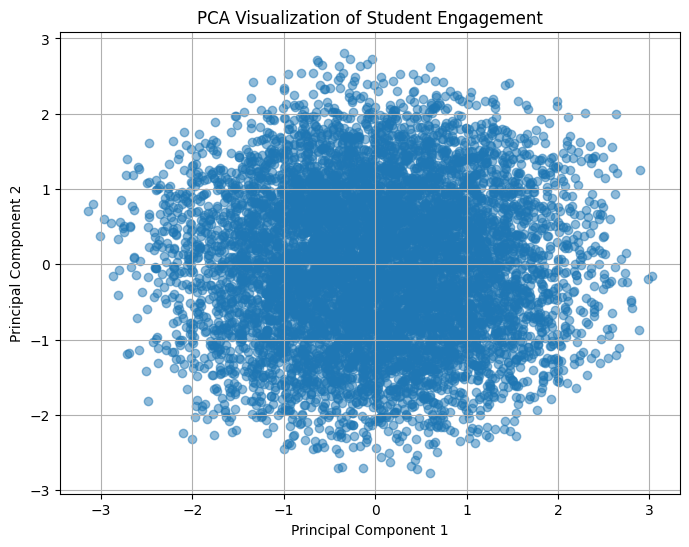

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Student Engagement")
plt.grid(True)
plt.show()

## 4️⃣ Key Insights for Final Report

### - PCA successfully reduced data dimensionality while preserving most of the information.

### - Student engagement can be segmented into different behavioral patterns.

### - These insights can help educators identify highly engaged students and those who may need additional support.